### 投资组合优化

In [1]:
import cvxpy as cp
import numpy as np
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pyplot as plt

import importlib
import simres.expr
importlib.reload(simres.expr)
from simres.expr import *

import simres.operators
importlib.reload(simres.operators)
from simres.operators import *

In [3]:
enddate='20251231'
executor = AlphaExecutor(data_dir=f'/Users/qiuyucheng/Documents/Alpha4/data/{enddate}',alpha_dir=f'../alphas/{enddate}')
executor.load_all_data()
# simres存放的是因子的回测数据
executor.load_all_simres()
# alphas会读取matrix文件夹下面35个因子的全量得分矩阵(parquet文件);
executor.load_all_alphas()

--- 正在初始化数据引擎 ---
已加载字段: [high] | 形状: (1326, 2674)
已加载字段: [close] | 形状: (1326, 2674)
已加载字段: [low] | 形状: (1326, 2674)
已加载字段: [csi_500_amount] | 形状: (1326, 2674)
已加载字段: [amount] | 形状: (1326, 2674)
已加载字段: [csi_500_low] | 形状: (1326, 2674)
已加载字段: [datestr] | 形状: (2674,)
已加载字段: [csi_500_open] | 形状: (1326, 2674)
已加载字段: [stock_list] | 形状: (1326,)
已加载字段: [csi_500_weight] | 形状: (1326, 2674)
已加载字段: [csi_500_volume] | 形状: (1326, 2674)
已加载字段: [csi_500_high] | 形状: (1326, 2674)
已加载字段: [industry] | 形状: (1326, 2674)
已加载字段: [volume] | 形状: (1326, 2674)
已加载字段: [csi_500_close] | 形状: (1326, 2674)
已加载字段: [open] | 形状: (1326, 2674)
已注入自定义算子: ['at_mask', 'at_nan2zero', 'at_zero2nan', 'cs_booksize', 'cs_group_quantile', 'cs_indneut', 'cs_rank', 'cs_zscore', 'ts_correlation', 'ts_delay', 'ts_delta', 'ts_fill', 'ts_kurtosis', 'ts_max', 'ts_mean', 'ts_min', 'ts_ols', 'ts_rank', 'ts_regression', 'ts_ret', 'ts_skewness', 'ts_std', 'ts_sum', 'ts_zscore']
--- 引擎就绪 ---

--- 正在初始化数据引擎 ---
success load alpha simres5000001

ts_mean(vwap-close,5)


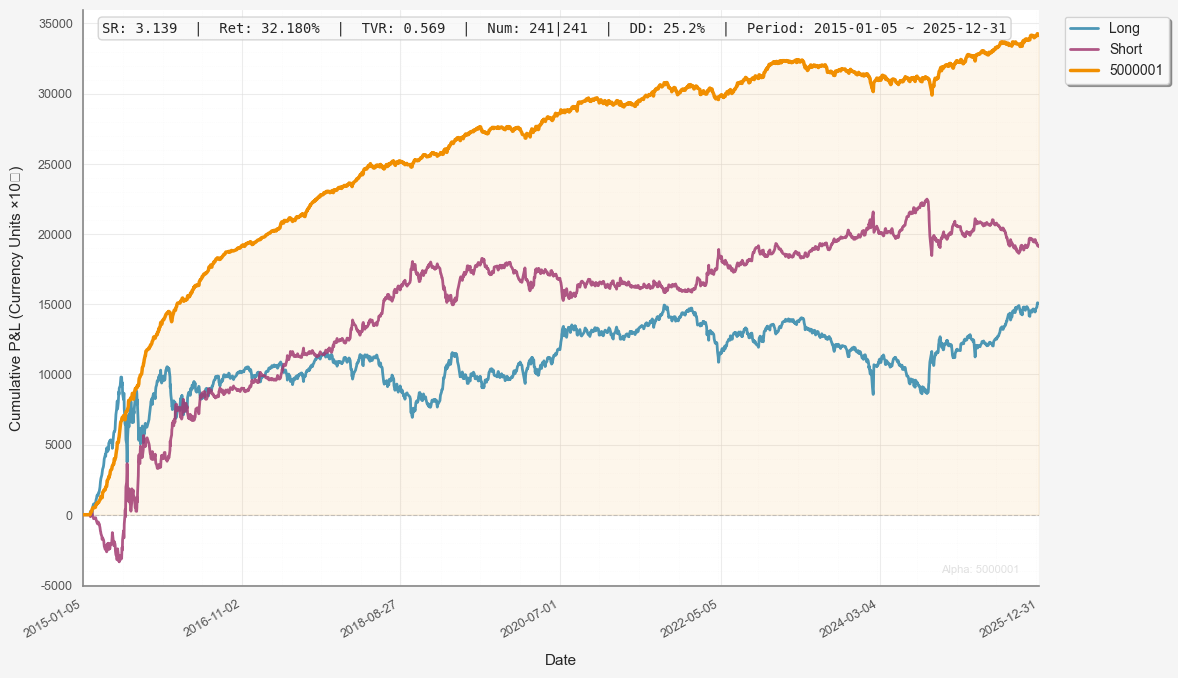

cs_rank(cs_rank(open)-cs_rank(ts_delay(close,1)))


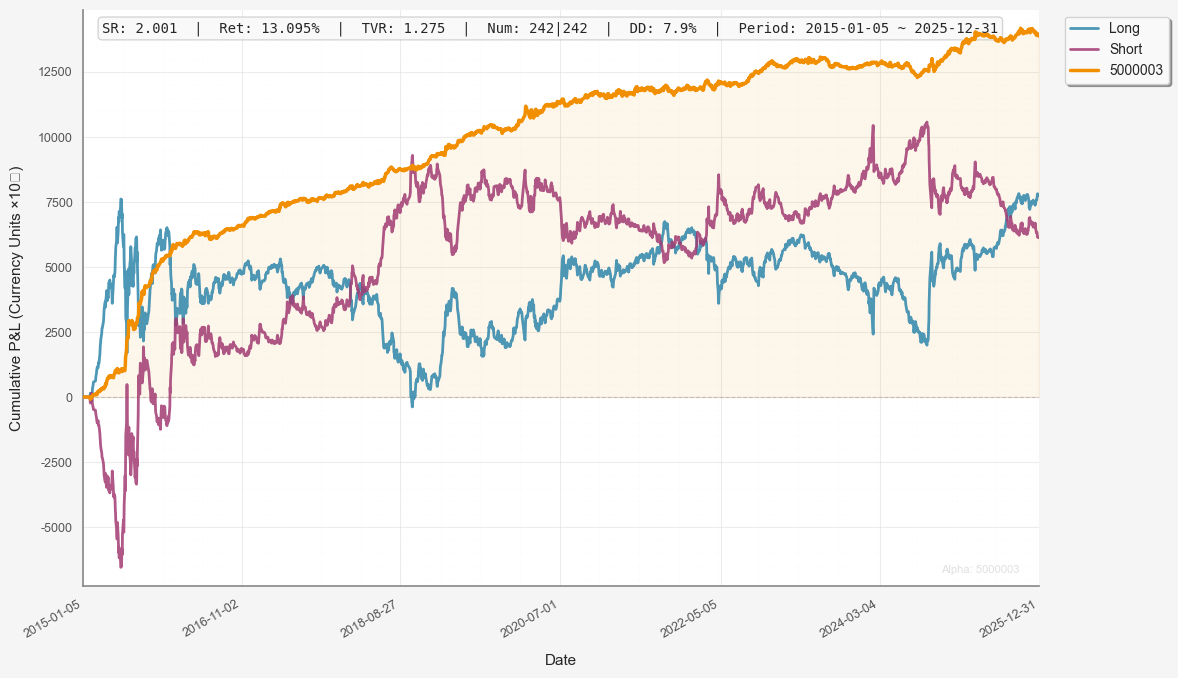

-ts_ols(close,ret1,10)[2]


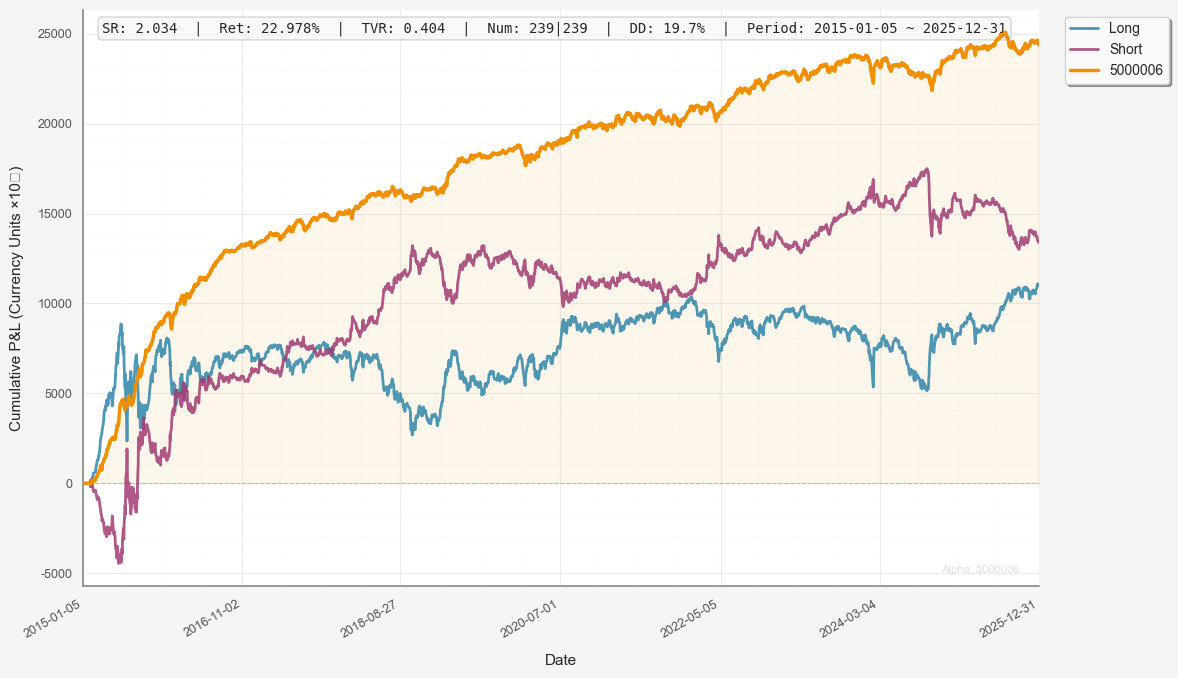

-ts_correlation(close,close/low-1,15)


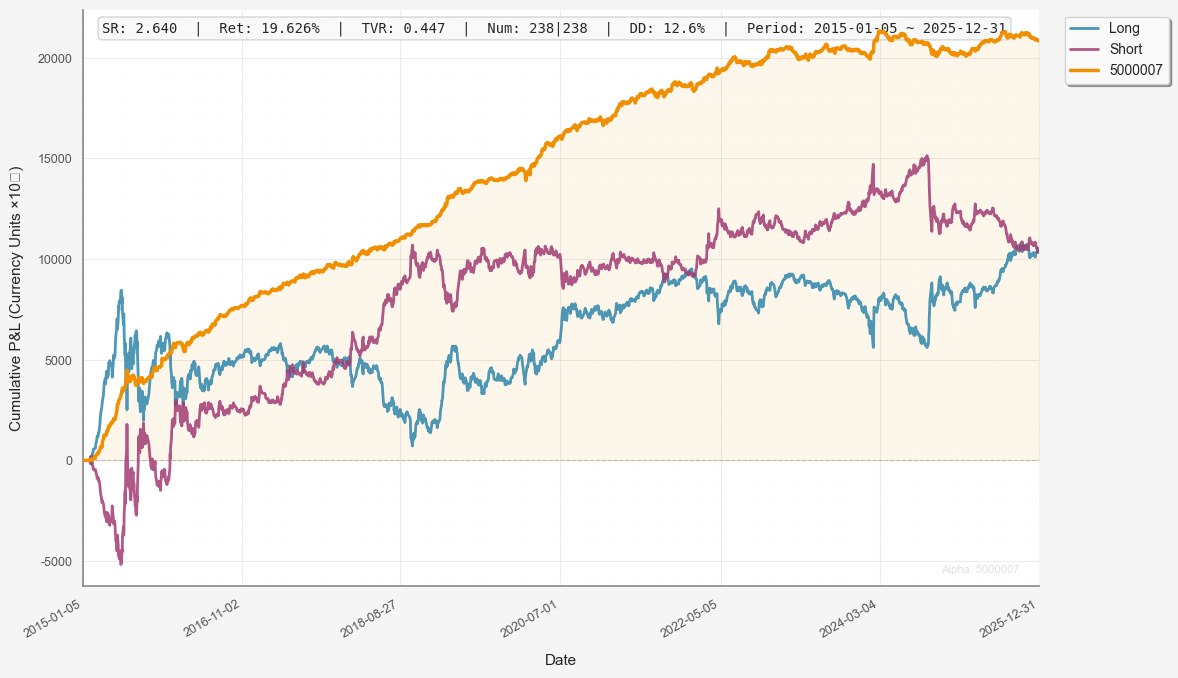

cs_indneut(high-close,cs_group_quantile(at_mask(close,ts_fill(csi_500_weight)>0),10))


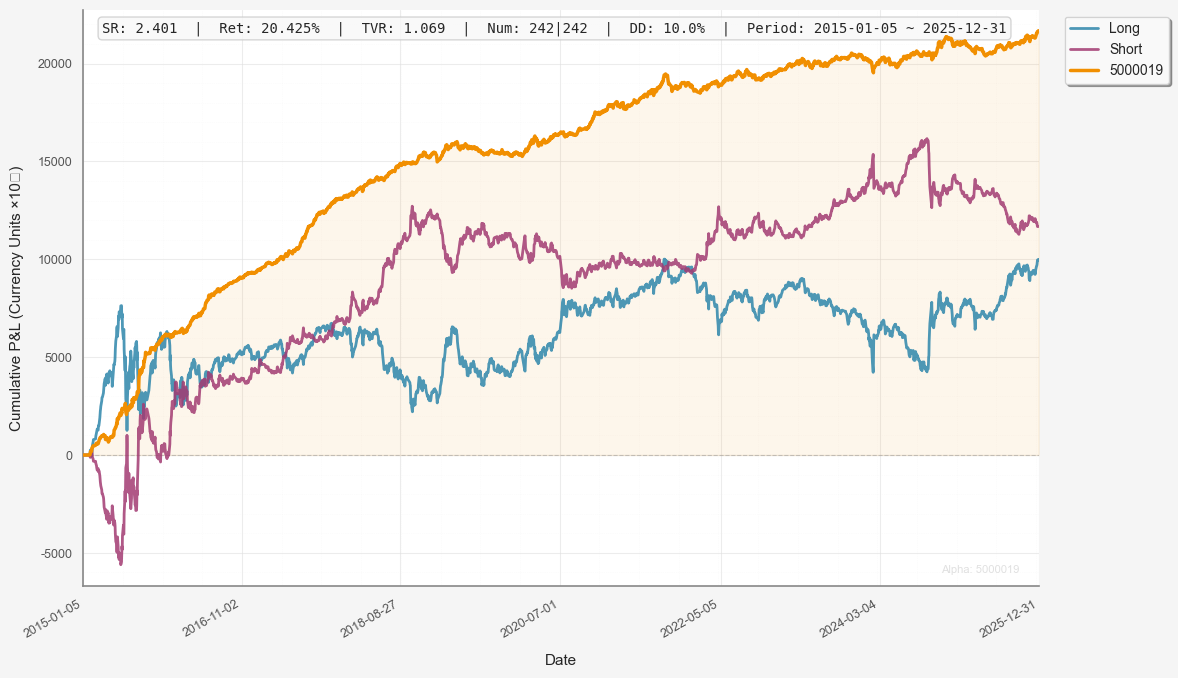

ts_mean(at_mask(vwap-close,cs_rank(at_mask(volume,ts_fill(csi_500_weight)>0))>0.5),2)


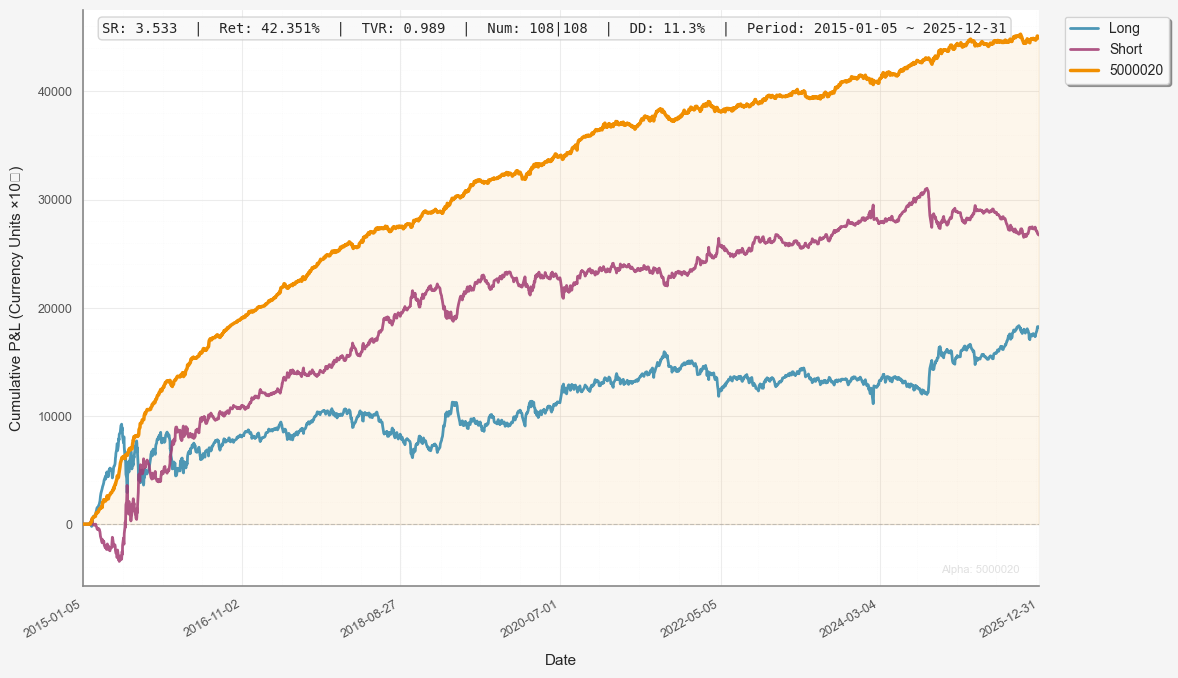

cs_indneut(ts_mean(open-close,2),cs_group_quantile(at_mask(ts_std(close,2),ts_fill(csi_500_weight)>0),50))


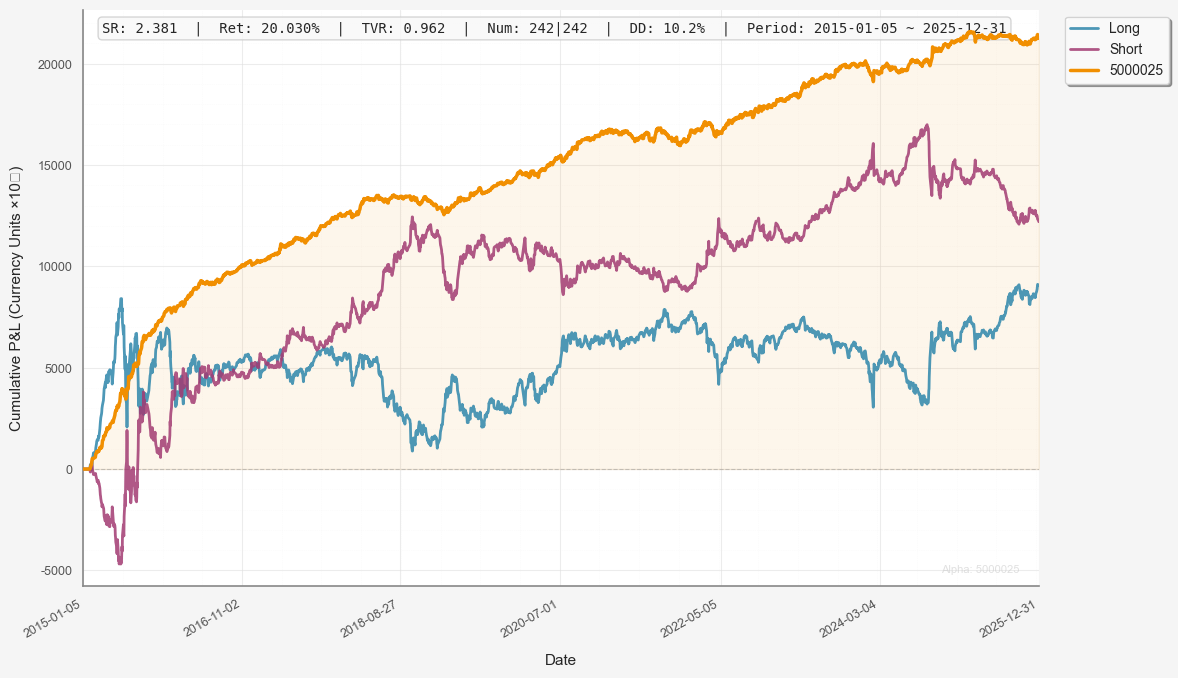

cs_indneut(ts_mean(ts_rank(open-close, 10), 5), cs_group_quantile(at_mask(ts_kurtosis(ret1, 20), ts_fill(csi_500_weight)>0), 10))


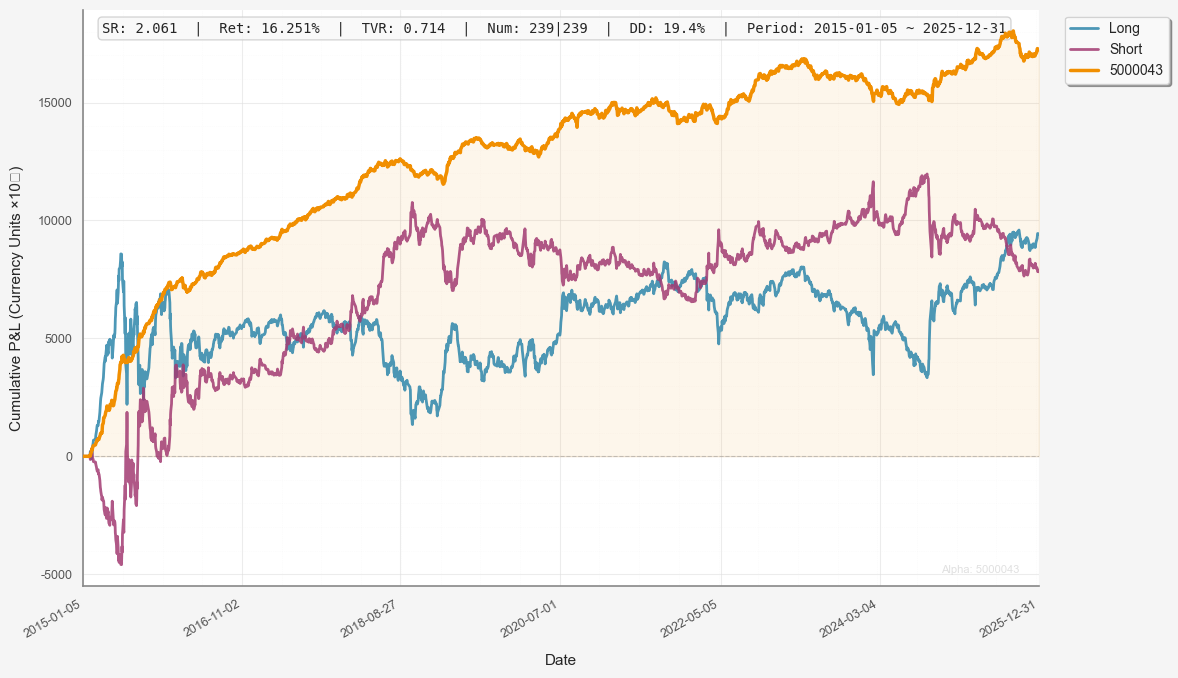

ts_ols(high/close-1, csi_500_ret1, 10)[2]


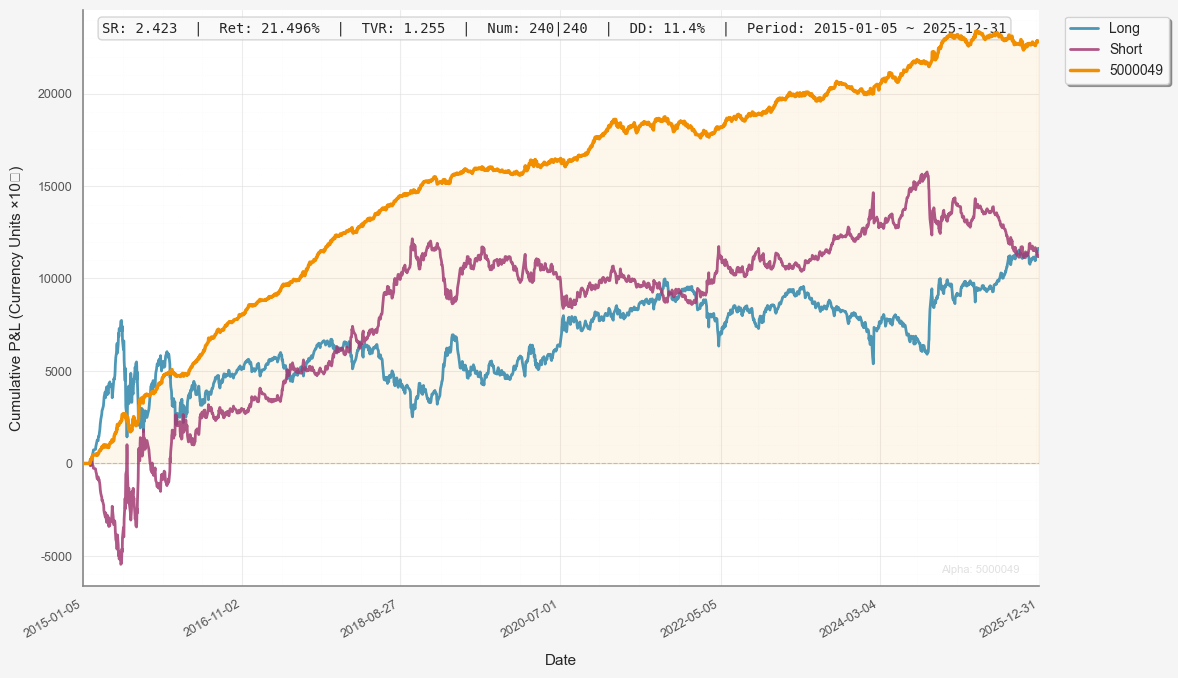

ts_ols(vwap-close, volume, 5)[2]


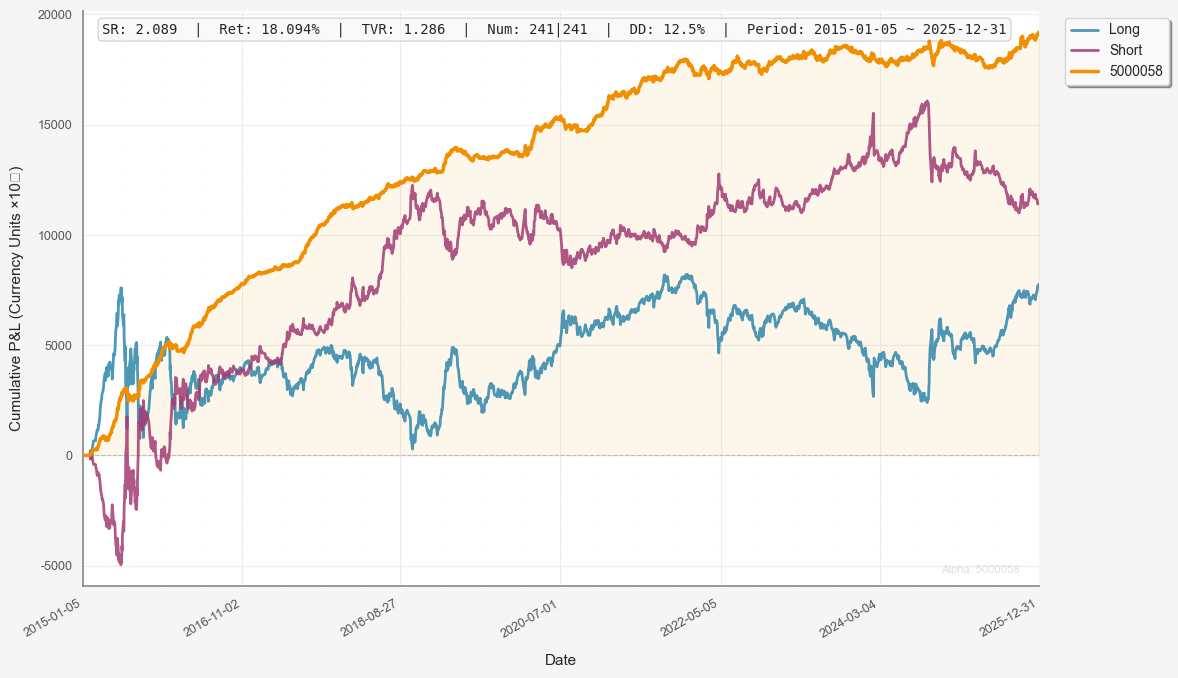

-cs_indneut(ts_mean(close/vwap-1,20), cs_group_quantile(at_mask(volume, ts_fill(csi_500_weight)>0),20))


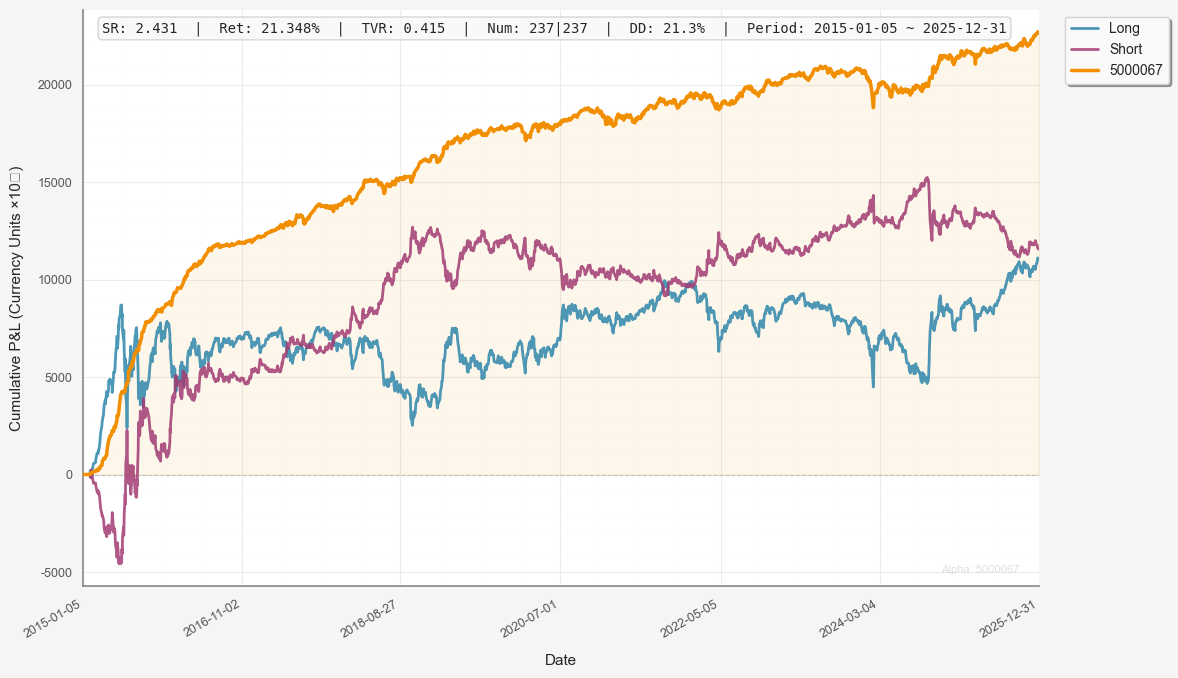

In [5]:
# 选择 Sharpe 大于 2 的因子
indices=[1,3,6,7,19,20,25,43,49,58,67]

# 定义保存图片的文件夹路径
output_dir = f'../alphas/{enddate}/figpnl/'
# 如果这个文件夹在本地不存在，自动把它创建出来
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"成功创建了图片保存目录: {output_dir}")

# 读取公式到alpha_list
with open ('csi500.txt', 'r') as f:
    alpha_list=f.read().split('\n')

#  最近6年的多空对冲曲线图，每一个因子跑一遍；
for i in indices:
    print(alpha_list[i-1])
    # 正常调用回测与区间截取保存
    executor.simres_cut(
        executor.alpha_pool[i-1],
        '20150101',
        '20251231',
        index=None,
        save_path=os.path.join(output_dir, executor.alpha_pool[i-1]['alpha_id'] + '.png') # 规范拼接路径并补上.png后缀
    )

# 你的控制台会打印出精锐因子的公式。
# 以及每个因子公式的回测曲线图

In [6]:
# 将因子对应的全量得分矩阵精准地抽出来
alpha_matrix=[executor.alpha_matrix[i-1] for i in indices]
# 多因子等权融合成合成因子 (combo)
# 把 23 个因子在每一天、对每一只股票的得分进行“等权相加平均”。
# 将相加后的综合得分在全市场（中证500内部）再做一次多空权重的归一化；
combo=op.cs_booksize(np.mean(np.concatenate([item[:,:,None] for item in alpha_matrix],axis=2),axis=2))
# 提取中证500指数的官方权重 (weight)
weight=op.cs_booksize(op.ts_fill(executor.context['csi_500_weight']))

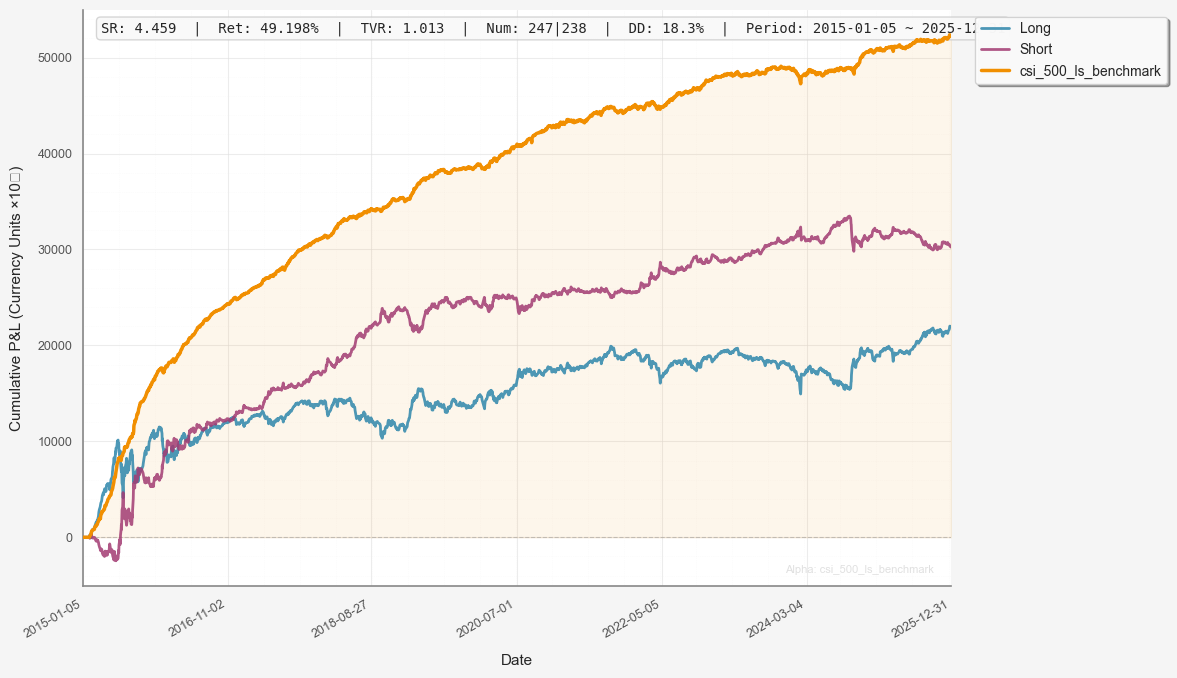

{'ann_ret': np.float32(0.49198),
 'ann_vol': np.float64(0.11033560359277579),
 'sr': np.float64(4.4589413608050155),
 'dd': np.float32(18.27621),
 'tvr_avg': np.float32(1.0133168)}

In [7]:
# 对于合成的combo因子进行回测，使用成交量加权平均价去做；
btresult=executor.backtest(combo,price='vwap')
executor.simres_cut(btresult,'20150101','20251231',index=None,alpha_id='csi_500_ls_benchmark')

通过cvxpy凸优化库,做一个指数增强策略;
计算你实盘每天到底应该买入哪些股票、买多少仓位，才能既不偏离中证500大盘，又能稳稳跑赢它;


凸优化解决什么问题：1. 买哪些股票,买多少仓位
凸优化的限制问题：1. 不能卖空 2. 必须满仓 3.不能偏离大盘太远 4.利用因子信号获取超额收益

In [8]:
# ls_matrix (传入了 combo)：多因子合成的combo因子
# index_weight_matrix (传入了 weight)：中证500指数每一天真实的成分股官方权重基准。
# 我的组合里任何一只股票的权重，跟大盘指数相比，偏离度绝对不能超过 ±3%
def lo_opt(ls_matrix, index_weight_matrix, offset_limit=0.4):
    n_stocks,t_days= ls_matrix.shape
    lo_matrix = np.full((n_stocks,t_days), np.nan)
    # cvxpy的核心概念;
    # Variable相当于方程中的X, Parameter相当于方程中的a,b参数;
    # w_lo[i] = 第i只股票的持仓权重（我们要求解的）
    # w_ls_param[i] = 第i只股票的Alpha信号（已知，每天变化）
    # w_idx_param[i] = 第i只股票的指数权重（已知，每天变化）
    w_lo = cp.Variable(n_stocks) #持仓权重;  
    w_ls_param = cp.Parameter(n_stocks) #每天的alpha信号
    w_idx_param = cp.Parameter(n_stocks) #指数权重
    
    # 目标函数，既要大盘，又要超额
    # 如果完全按照alpha信号操作,可能风险太大，因此要综合大盘的收益;
    alpha_scale = 100  # Alpha信号放大倍数，让offset_limit参数生效
    target_w = w_idx_param + alpha_scale * w_ls_param  # 理想状态 = 指数权重 + 放大后的Alpha超额得分
    objective = cp.Minimize(cp.sum_squares(w_lo - target_w))   # 现实与理想的差距最小化

    # 基础约束
    base_constraints = [
    w_lo >= 0,                           # 锁一：纯多头约束！实盘不准卖空，每只股票持仓必须 >= 0
    cp.sum(w_lo) == 1,                   # 锁二：满仓约束！所有的股票资金权重加起来必须等于 100% 满仓
    w_lo - w_idx_param <= offset_limit,  # 锁三：防暴走约束！不能比大盘超配超过 3%
    w_idx_param - w_lo <= offset_limit   # 锁四：防漏球约束！不能比大盘低配超过 3%
]
    #  它是按照 天 去优化的
    for t in tqdm(range(t_days)):
        # 第t天的alpha信号(所有股票,1326 x 1)
        curr_ls = np.nan_to_num(ls_matrix[:,t])
        # 第t天的指数权重(所有股票,1326 x 1)
        # nan_to_num的作用就是将NaN替换为0
        curr_idx = np.nan_to_num(index_weight_matrix[:,t])
        
        if np.sum(curr_idx) == 0:
            continue

        # 设置cvxpy的参数值
        w_ls_param.value = curr_ls # 第t天的alpha信号
        w_idx_param.value = curr_idx # 第t天的指数权重
        
        # --- 核心修改：动态增加 Mask 约束 ---
        # 找出 index_weight <= 0 的索引（即不在成分股里的股票）
        mask = (curr_idx <= 0)
        # 增加约束：这些股票的权重强制为 0,即非成分股不能买入;
        current_constraints = base_constraints + [w_lo[mask] == 0]
        
        prob = cp.Problem(objective, current_constraints)
        
        try:
            # 提高精度并求解
            # 使用OSQP求解器; 热启动; 绝对误差容忍; 相对误差容忍度
            prob.solve(solver=cp.OSQP, warm_start=True, eps_abs=1e-7, eps_rel=1e-7)
            # OPTIMAL找到最优解; OPTIMAL_INACCURATE 找到近似最优解;
            # INFEASIBLE 无解; UNBOUNDED 无界解;SOLVER_ERROR 求解器错误
            # 这里我们只关注 OPTIMAL 和 OPTIMAL_INACCURATE 两种情况
            if prob.status in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
                # 从求解其中提取最有权重向量；
                res = w_lo.value
                # 针对数值精度问题，进行物理截断和重新归一化
                res = np.maximum(res, 0)
                res[mask] = 0 # 再次确保 mask 掉的位为 0
                
                # 归一化权重向量，确保总和为 1
                if np.sum(res) > 0:
                    lo_matrix[:,t] = res / np.sum(res)
            else:
                # 如果无解，通常是因为成分股太少，offset_limit 限制得太死
                # 此时可以 fallback 到指数权重，或者调大偏移
                lo_matrix[:,t] = curr_idx
        except Exception as e:
            print(f"Error at day {t}: {e}")
            
    return lo_matrix

lo_matrix=lo_opt(combo, weight, offset_limit=0.01)

100%|██████████| 2674/2674 [07:45<00:00,  5.75it/s]


🚀 正在绘制中证500纯正指数增强(Alpha)d超额收益曲线...


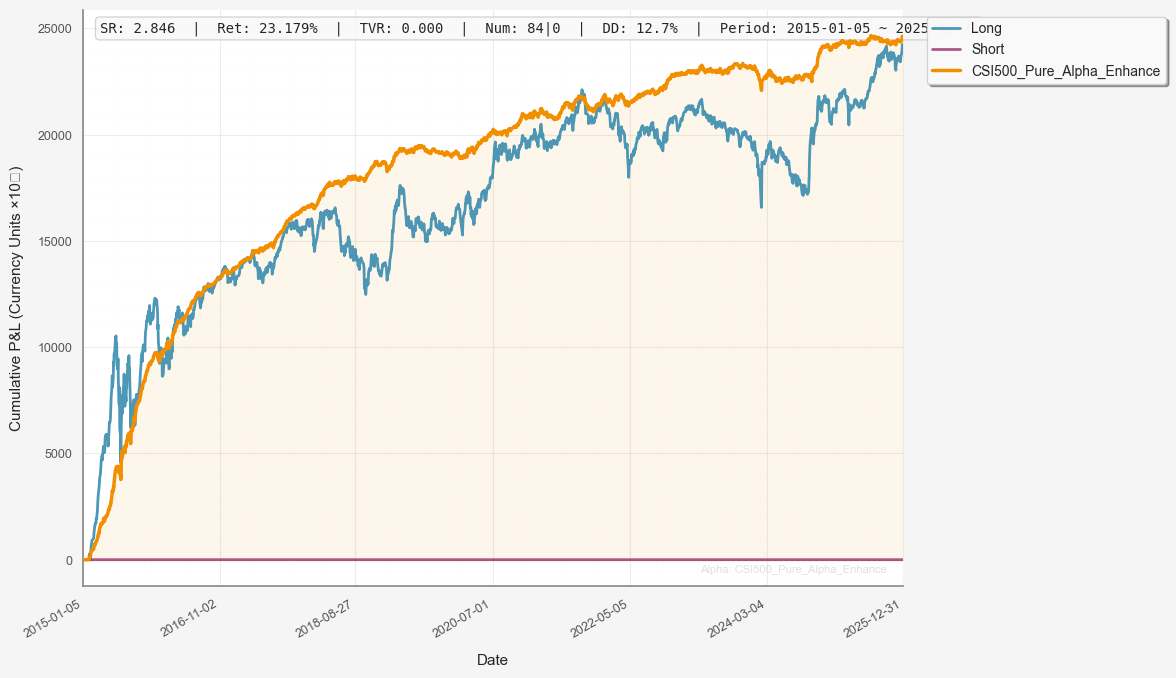

{'ann_ret': np.float64(0.2317858604905897),
 'ann_vol': np.float64(0.08144382475146034),
 'sr': np.float64(2.8459599140625285),
 'dd': np.float64(12.713632764772301),
 'tvr_avg': np.float64(0.0)}

In [9]:
# 中证500指数增强纯超额收益验证
import copy
# 1. 运行你的凸优化纯多头组合回测（你的实盘模拟持仓）
bt_lo = executor.backtest(lo_matrix, price='vwap')
# 2. 运行中证500官方指数本身的持仓回测（大盘基准持仓）
bt_idx = executor.backtest(weight, price='vwap')
# 3. 创建一个干净的“纯超额对账账本”对象
bt_enhancement = copy.deepcopy(bt_lo)
# 主动超额收益 = 你的多头持仓收益 - 指数基准收益
bt_enhancement['net_ret'] = bt_lo['net_ret'] - bt_idx['net_ret']
# 23 个因子通过凸优化后榨出来的纯主动超额收益（Alpha）曲线图
print("🚀 正在绘制中证500纯正指数增强(Alpha)d超额收益曲线...")
executor.simres_cut(
    res=bt_enhancement,
    start_date='20150101',
    end_date='20251231',
    index=None,                     
    alpha_id='CSI500_Pure_Alpha_Enhance' # <-- 中证500纯超额指数增强
)

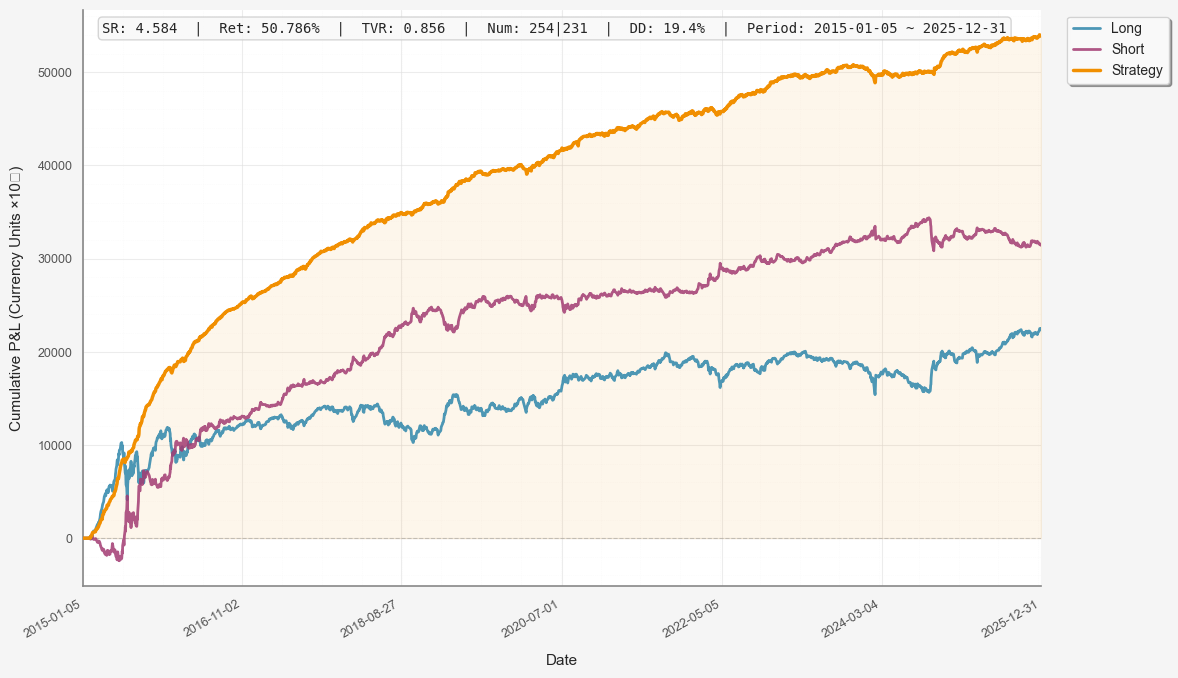

{'ann_ret': np.float32(0.50785524),
 'ann_vol': np.float64(0.11079020565024725),
 'sr': np.float64(4.583936220260735),
 'dd': np.float32(19.406797),
 'tvr_avg': np.float32(0.8557727)}

In [9]:
btresult=executor.backtest(combo,price='vwap')
executor.simres_cut(btresult,'20150101','20251231',index=None)

对于CVXPY凸优化,如果要提升指增策略的收益：
1. 调大偏离度；将offset_limit调大，允许股票权重偏离大盘指数更多；
2. 对因子池改变,增强厉害的因子
3. 优化因子的权重,目前是等权融合；【还可以根据因子IC值加权】【机器学习树模型优化权重】